<a href="https://colab.research.google.com/github/Rakesh-562/ScoreStats/blob/main/Topsis_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
bat=pd.read_csv("batting_stats_for_icc_mens_t20_world_cup_2024.csv")
bowl=pd.read_csv("bowling_stats_for_icc_mens_t20_world_cup_2024.csv")
wk=pd.read_csv("wk_stats_for_icc_mens_t20_world_cup_2024.csv")
# bat.head()
bowl.head()
# wk.head()

,Player,Team,Mat,Inns,Balls,Mdns,Runs,Wkts,BBI,Ave,Econ,SR,5,10,Ct
0,NP Kenjige,United States of America,4,4,60,0,89,3,30-Mar,29.66,8.90,20,0,0,0
1,Abbas Afridi,Pakistan,1,1,18,0,31,0,-,0.00,10.33,-,0,0,0
2,MR Adair,Ireland,3,3,72,0,74,3,23-Jan,24.66,6.16,24,0,0,1
3,AC Agar,Australia,2,2,48,1,56,1,Jan-39,56.00,7.00,48,0,0,1
4,DS Airee,Nepal,3,3,57,0,49,6,21-Mar,8.16,5.15,9.5,0,0,3


In [ ]:
team_name="India"
ind_bat=bat[bat["Team"]==team_name]
ind_bowl=bowl[bowl["Team"]==team_name]
ind_wk=wk[wk["Team"]==team_name]

In [ ]:
# normalize helper
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

# Available columns: ['Ave', 'SR', '100', '50']
bat["avg_norm"] = normalize(bat["Ave"])
bat["sr_norm"] = normalize(bat["SR"])
bat["milestone_score"] = normalize(bat["50"] + 2 * bat["100"])

# New composite batting index based on available data
ind_bat["batting_index"] = (
    0.40 * bat["avg_norm"] +
    0.40 * bat["sr_norm"] +
    0.20 * bat["milestone_score"]
)

print("Batting Index calculated successfully.")
bat[['Player', 'Ave', 'SR', 'batting_index']].sort_values(by='batting_index', ascending=False).head(10)

Batting Index calculated successfully.


/tmp/ipykernel_2150/645626436.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ind_bat["batting_index"] = (


KeyError: "['batting_index'] not in index"

In [ ]:
print("Available batting columns:", bat.columns.tolist())
bat.head()

In [ ]:
# Calculate bowling index using inverse of Runs and Econ, plus Wickets
ind_bowl["runs_inv_norm"] = 1 - normalize(ind_bowl["Runs"])
ind_bowl["eco_inv_norm"] = 1 - normalize(ind_bowl["Econ"])
ind_bowl["wkts_norm"] = normalize(ind_bowl["Wkts"])

# Composite Bowling Index
# Giving weight to economy, run control, and wicket taking
ind_bowl["bowling_index"] = (
    0.40 * ind_bowl["wkts_norm"] +
    0.30 * ind_bowl["eco_inv_norm"] +
    0.30 * ind_bowl["runs_inv_norm"]
)

print("Bowling Index calculated successfully.")
ind_bowl[['Player', 'Wkts', 'Econ', 'Runs', 'bowling_index']].sort_values(by='bowling_index', ascending=False).head(10)

In [ ]:
ind_wk["is_wk"] = 1
ind_bat["is_wk"] = 0

ind_bat = pd.concat([bat, wk], ignore_index=True)

In [ ]:
# Recalculate batting index on the combined 'ind_bat' dataframe to ensure it exists
ind_bat['Ave'] = ind_bat['Ave'].fillna(0)
ind_bat['SR'] = ind_bat['SR'].fillna(0)
ind_bat['100'] = ind_bat['100'].fillna(0)
ind_bat['50'] = ind_bat['50'].fillna(0)

ind_bat["avg_norm"] = normalize(ind_bat["Ave"])
ind_bat["sr_norm"] = normalize(ind_bat["SR"])
ind_bat["milestone_score"] = normalize(ind_bat["50"] + 2 * ind_bat["100"])

ind_bat["batting_index"] = (
    0.40 * ind_bat["avg_norm"] +
    0.40 * ind_bat["sr_norm"] +
    0.20 * ind_bat["milestone_score"]
)

# Now extract the matrices
bat_matrix = ind_bat[["batting_index", "Ave", "SR"]].fillna(0)
bowl_matrix = ind_bowl[["bowling_index", "Econ", "Wkts"]].fillna(0)

print("Matrices created successfully.")
print("Batting Matrix shape:", bat_matrix.shape)
print("Bowling Matrix shape:", bowl_matrix.shape)

In [ ]:
def topsis(matrix, weights):
    matrix = matrix.values.astype(float)

    # Step 1: Normalize
    norm = matrix / np.sqrt((matrix**2).sum(axis=0))

    # Step 2: Weighted matrix
    weighted = norm * weights

    # Step 3: Ideal best & worst
    ideal_best = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)

    # Step 4: Distance
    d_pos = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
    d_neg = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

    # Step 5: Score
    score = d_neg / (d_pos + d_neg)

    return score

In [ ]:
# Adjusting weights to match the 3 columns in our matrices
bat_weights = np.array([0.4, 0.3, 0.3])
bowl_weights = np.array([0.4, 0.3, 0.3])

ind_bat["score"] = topsis(bat_matrix, bat_weights)
ind_bowl["score"] = topsis(bowl_matrix, bowl_weights)

print("TOPSIS scores calculated successfully.")

In [ ]:
ind_bat = ind_bat.sort_values(by="score", ascending=False)
ind_bowl = ind_bowl.sort_values(by="score", ascending=False)

In [ ]:
from typing_extensions import final
selected_players = set()

final_team = []

# 1️⃣ Select Wicketkeeper
wk_player = bat[bat["is_wk"] == 1].sort_values(by="score", ascending=False)

for _, row in wk_player.iterrows():
    if row["Player"] not in selected_players:
        final_team.append(row)
        selected_players.add(row["Player"])
        break
wk_player
len(final_team)

In [ ]:
batsmen_pool = bat[bat["is_wk"] == 0].sort_values(by="score", ascending=False)

count = len(final_team)-1
for _, row in batsmen_pool.iterrows():
    if count >= 4:
        break
    if row["Player"] not in selected_players:
        final_team.append(row)
        selected_players.add(row["Player"])
        count += 1
batsmen=pd.DataFrame(final_team)

In [ ]:
bowlers_pool = bowl.sort_values(by="score", ascending=False)

count = len(final_team)-5
for _, row in bowlers_pool.iterrows():
    if count == 3:
        break
    if row["Player"] not in selected_players:
        final_team.append(row)
        selected_players.add(row["Player"])
        count += 1
bowlers=pd.DataFrame(final_team)
bowlers


In [ ]:
allrounders = pd.merge(bat, bowl, on="Player")

# combine both scores
allrounders["final_score"] = 0.6 * allrounders["batting_index"] + 0.4 * allrounders["bowling_index"]

allrounders = allrounders.sort_values(by="final_score", ascending=False)

count = len()
for _, row in allrounders.iterrows():
    if count == 3:
        break
    if row["Player"] not in selected_players:
        final_team.append(row)
        selected_players.add(row["Player"])
        count += 1


In [89]:
final_team = pd.concat([
    wk_player,
    batsmen,
    bowlers,
    ind_allrounders
])

print("Predicted INDIA Playing XI ")
final_team

Predicted INDIA Playing XI 


,Player,Team,Mat,Inns,NO,Runs,HS,Ave,SR,100,...,Team_y,Mat_y,Inns_y,Runs_y,Ave_y,SR_y,Ct_y,avg_norm_y,score_y,final_score
247,RR Pant,India,8.0,8.0,NaN,NaN,NaN,0.00,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,RR Pant,India,8.0,8.0,NaN,NaN,NaN,0.00,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,HH Pandya,India,8.0,6.0,3.0,144.0,50*,48.00,151.57,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
202,RG Sharma,India,8.0,8.0,1.0,257.0,92,36.71,156.7,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,SA Yadav,India,8.0,8.0,1.0,199.0,53,28.42,135.37,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,AR Patel,India,8.0,5.0,1.0,92.0,47,23.00,139.39,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,RR Pant,India,8.0,8.0,NaN,NaN,NaN,0.00,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,HH Pandya,India,8.0,6.0,3.0,144.0,50*,48.00,151.57,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
202,RG Sharma,India,8.0,8.0,1.0,257.0,92,36.71,156.7,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,SA Yadav,India,8.0,8.0,1.0,199.0,53,28.42,135.37,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
actual_df = pd.read_csv("india_t20_wc_2024_playing_xi.csv")

actual_df.head()

,match_id,date,opponent,player,position
0,1415725,2024-06-12,United States of America,RG Sharma,1
1,1415725,2024-06-12,United States of America,V Kohli,2
2,1415725,2024-06-12,United States of America,RR Pant,3
3,1415725,2024-06-12,United States of America,SA Yadav,4
4,1415725,2024-06-12,United States of America,S Dube,5


In [101]:
def get_predicted_xi(match_id):
    """
    Replace this with your real model output
    Must return list of 11 player names
    """
    return final_team["Player"].tolist()

In [93]:
def basic_accuracy(predicted, actual):
    predicted_set = set(predicted)
    actual_set = set(actual)
    correct = len(predicted_set & actual_set)
    return correct / 11, correct


In [94]:
def precision_recall_f1(predicted, actual):
    predicted_set = set(predicted)
    actual_set = set(actual)

    correct = len(predicted_set & actual_set)

    precision = correct / len(predicted_set)
    recall = correct / len(actual_set)

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1

In [95]:
def jaccard_similarity(predicted, actual):
    pred = set(predicted)
    act = set(actual)

    intersection = len(pred & act)
    union = len(pred | act)

    return intersection / union


In [96]:

def role_accuracy(pred_df, actual_df):
    roles = ["batsman", "bowler", "allrounder", "wk"]
    result = {}

    for role in roles:
        pred = set(pred_df[pred_df["role"] == role]["player_name"])
        act = set(actual_df[actual_df["role"] == role]["player_name"])

        if len(act) == 0:
            continue

        correct = len(pred & act)
        result[role] = correct / len(act)

    return result


In [102]:
results = []

for match_id in actual_df["match_id"].unique():
    actual_xi = actual_df[actual_df["match_id"] == match_id]["player"].tolist()

    predicted_xi = get_predicted_xi(match_id)

    acc, correct = basic_accuracy(predicted_xi, actual_xi)
    precision, recall, f1 = precision_recall_f1(predicted_xi, actual_xi)
    jaccard = jaccard_similarity(predicted_xi, actual_xi)

    results.append({
        "match_id": match_id,
        "accuracy": acc,
        "correct_players": correct,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "jaccard": jaccard
    })

results_df = pd.DataFrame(results)
results_df

,match_id,accuracy,correct_players,precision,recall,f1_score,jaccard
0,1415725,0.909091,10,0.909091,0.909091,0.909091,0.833333
1,1415747,0.909091,10,0.909091,0.909091,0.909091,0.833333
2,1415755,0.909091,10,0.909091,0.909091,0.909091,0.833333
3,1415719,0.909091,10,0.909091,0.909091,0.909091,0.833333
4,1415754,0.909091,10,0.909091,0.909091,0.909091,0.833333
5,1415751,0.909091,10,0.909091,0.909091,0.909091,0.833333
6,1415708,0.909091,10,0.909091,0.909091,0.909091,0.833333


In [103]:

print("📊 OVERALL PERFORMANCE")
print("----------------------")
print("Avg Accuracy:", results_df["accuracy"].mean())
print("Avg F1 Score:", results_df["f1_score"].mean())
print("Avg Jaccard:", results_df["jaccard"].mean())


📊 OVERALL PERFORMANCE
----------------------
Avg Accuracy: 0.9090909090909091
Avg F1 Score: 0.9090909090909091
Avg Jaccard: 0.8333333333333333


In [107]:
role_results = []

for match_id in actual_df["match_id"].unique():
    actual_match = actual_df[actual_df["match_id"] == match_id]

    predicted_xi = get_predicted_xi(match_id)

    pred_df = actual_match.copy()
    pred_df = pred_df[pred_df["player"].isin(predicted_xi)]

    role_acc = role_accuracy(pred_df, actual_match)
    role_acc["match_id"] = match_id

    role_results.append(role_acc)

role_df = pd.DataFrame(role_results)
role_df

,batsman,allrounder,wk,match_id,bowler
0,0.666667,1.0,1.0,1415725,NaN
1,0.666667,1.0,1.0,1415747,1.0
2,0.666667,1.0,1.0,1415755,1.0
3,0.666667,1.0,1.0,1415719,NaN
4,0.666667,1.0,1.0,1415754,1.0
5,0.666667,1.0,1.0,1415751,1.0
6,0.666667,1.0,1.0,1415708,NaN


In [106]:
def assign_role(player_name):
    # Check Wicket-keeper
    if player_name in ind_wk['Player'].values:
        return 'wk'
    # Check Allrounder (exists in both batting and bowling filtered lists)
    elif player_name in ind_bat['Player'].values and player_name in ind_bowl['Player'].values:
        return 'allrounder'
    # Check Bowler
    elif player_name in ind_bowl['Player'].values:
        return 'bowler'
    # Default to batsman
    else:
        return 'batsman'

# Apply the role to the actual data
actual_df['role'] = actual_df['player'].apply(assign_role)
# The function role_accuracy also looks for 'player_name', so let's ensure that exists
actual_df['player_name'] = actual_df['player']

print("Role column added to actual_df:")
display(actual_df[['player', 'role']].drop_duplicates())

Role column added to actual_df:


,player,role
0,RG Sharma,batsman
1,V Kohli,batsman
2,RR Pant,wk
3,SA Yadav,batsman
4,S Dube,allrounder
5,HH Pandya,allrounder
6,RA Jadeja,allrounder
7,AR Patel,allrounder
8,Arshdeep Singh,allrounder
9,JJ Bumrah,allrounder


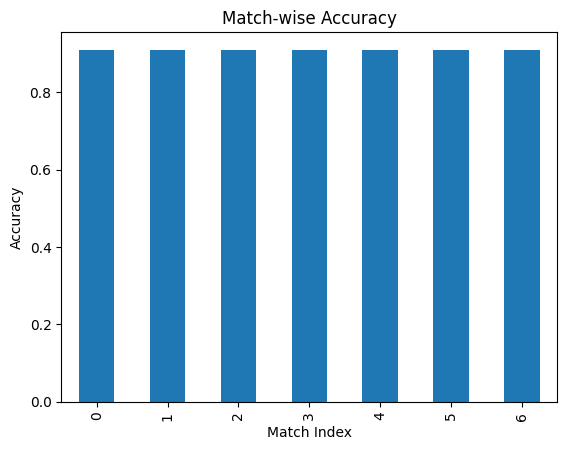

In [108]:

import matplotlib.pyplot as plt

plt.figure()
results_df["accuracy"].plot(kind="bar")
plt.title("Match-wise Accuracy")
plt.xlabel("Match Index")
plt.ylabel("Accuracy")
plt.show()